In [162]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [5]:
df = pd.read_csv('List of Countries by Sugarcane Production.csv')

In [7]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [9]:
df.shape

(103, 7)

# Data Cleaning

In [12]:
df['Production (Tons)'] = df['Production (Tons)'].str.replace('.','')
df['Production per Person (Kg)'] = df['Production per Person (Kg)'].str.replace('.','').str.replace(',','.')
df['Acreage (Hectare)'] = df['Acreage (Hectare)'].str.replace('.','')
df['Yield (Kg / Hectare)'] = df['Yield (Kg / Hectare)'].str.replace('.','').str.replace(',','.')

In [14]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [16]:
df.rename(columns = {'Production (Tons)':'Production(Tons)'},inplace= True)
df.rename(columns = {'Production per Person (Kg))':'Production per Person(Kg))'},inplace= True)
df.rename(columns = {'Acreage (Hectare)':'Acreage(Hectare)'},inplace= True)
df.rename(columns = {'Yield (Kg / Hectare)':'Yield(Kg/Hectare)'},inplace= True)

In [18]:
df.head()

,Unnamed: 0,Country,Continent,Production(Tons),Production per Person (Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [20]:
df.isnull().sum()

Unnamed: 0                    0
Country                       0
Continent                     0
Production(Tons)              0
Production per Person (Kg)    0
Acreage(Hectare)              1
Yield(Kg/Hectare)             1
dtype: int64

In [22]:
df[df['Acreage(Hectare)'].isnull()]

,Unnamed: 0,Country,Continent,Production(Tons),Production per Person (Kg),Acreage(Hectare),Yield(Kg/Hectare)
99,99,Djibouti,Africa,53,51,NaN,NaN


In [24]:
df = df.dropna().reset_index()

In [26]:
df.head()

,index,Unnamed: 0,Country,Continent,Production(Tons),Production per Person (Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [28]:
df.drop(['index','Unnamed: 0'], axis = 1, inplace = True)

In [30]:
df.head()

,Country,Continent,Production(Tons),Production per Person (Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


In [32]:
df.dtypes

Country                       object
Continent                     object
Production(Tons)              object
Production per Person (Kg)    object
Acreage(Hectare)              object
Yield(Kg/Hectare)             object
dtype: object

In [42]:
df['Production(Tons)'] = df['Production(Tons)'].astype(float)
df['Production per Person (Kg)'] = df['Production per Person (Kg)'].astype(float)
df['Acreage(Hectare)'] = df['Acreage(Hectare)'].astype(float)
df['Yield(Kg/Hectare)'] = df['Yield(Kg/Hectare)'].astype(float)

In [54]:
df.dtypes

Country                        object
Continent                      object
Production(Tons)              float64
Production per Person (Kg)    float64
Acreage(Hectare)              float64
Yield(Kg/Hectare)             float64
dtype: object

In [92]:
df.head()

,Country,Continent,Production(Tons),Production per Person (Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


In [63]:
df.nunique()

Country                       102
Continent                       6
Production(Tons)              102
Production per Person (Kg)    101
Acreage(Hectare)              101
Yield(Kg/Hectare)             102
dtype: int64

### Now the data is cleaned

# UniVariate Analysis

## Q1).How Many Countries Produce Sugarcane from Each Continent?

In [71]:
df['Continent'].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

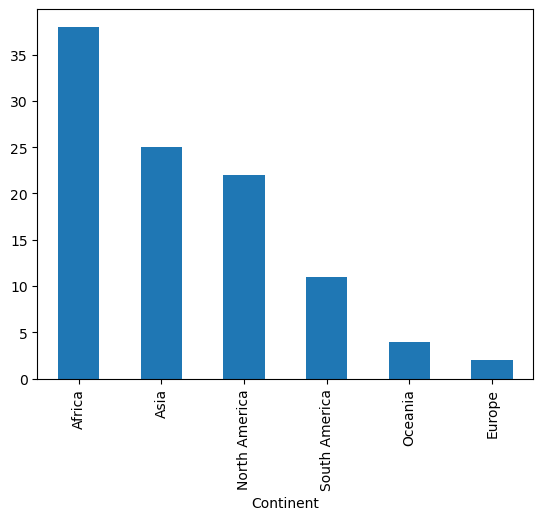

In [73]:
df['Continent'].value_counts().plot(kind='bar')

## Now Max Columns are Numerical lets plot The Distribution

## Distribution plot

/var/folders/ds/9lm2vt094hjggynjhw3k36t40000gn/T/ipykernel_46428/2058441867.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Production(Tons)'])
/var/folders/ds/9lm2vt094hjggynjhw3k36t40000gn/T/ipykernel_46428/2058441867.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Production p

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Density'>

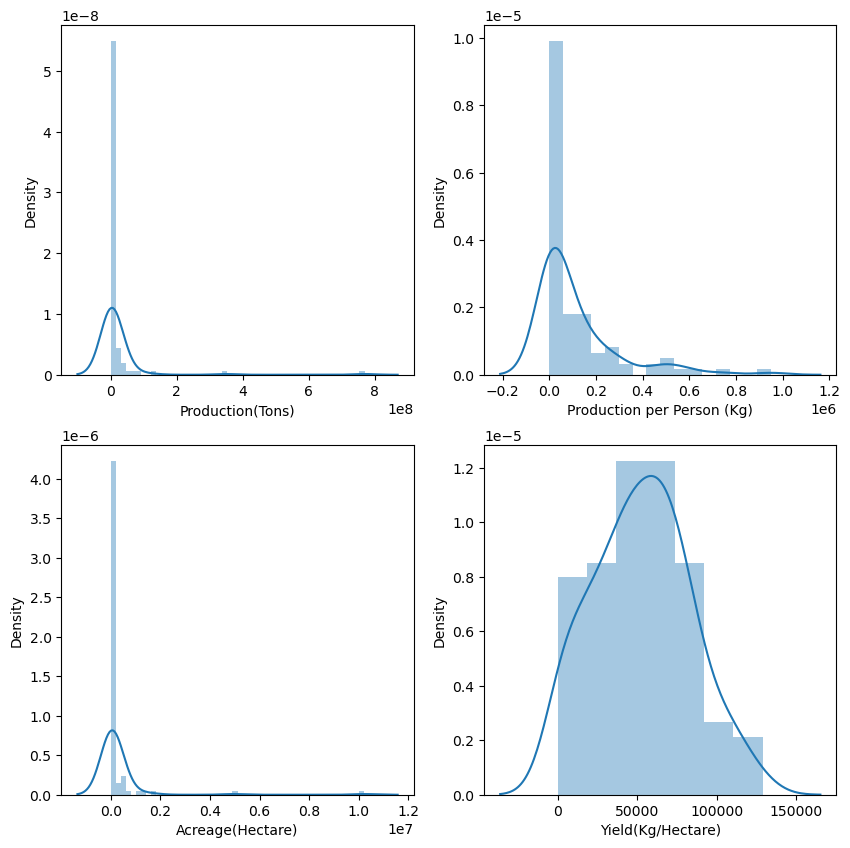

In [99]:
plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
sns.distplot(df['Production(Tons)'])
plt.subplot(2,2,2)
sns.distplot(df['Production per Person (Kg)'])
plt.subplot(2,2,3)
sns.distplot(df['Acreage(Hectare)'])
plt.subplot(2,2,4)
sns.distplot(df['Yield(Kg/Hectare)'])

## Checking For Outliers

## Box Plot

<Axes: ylabel='Yield(Kg/Hectare)'>

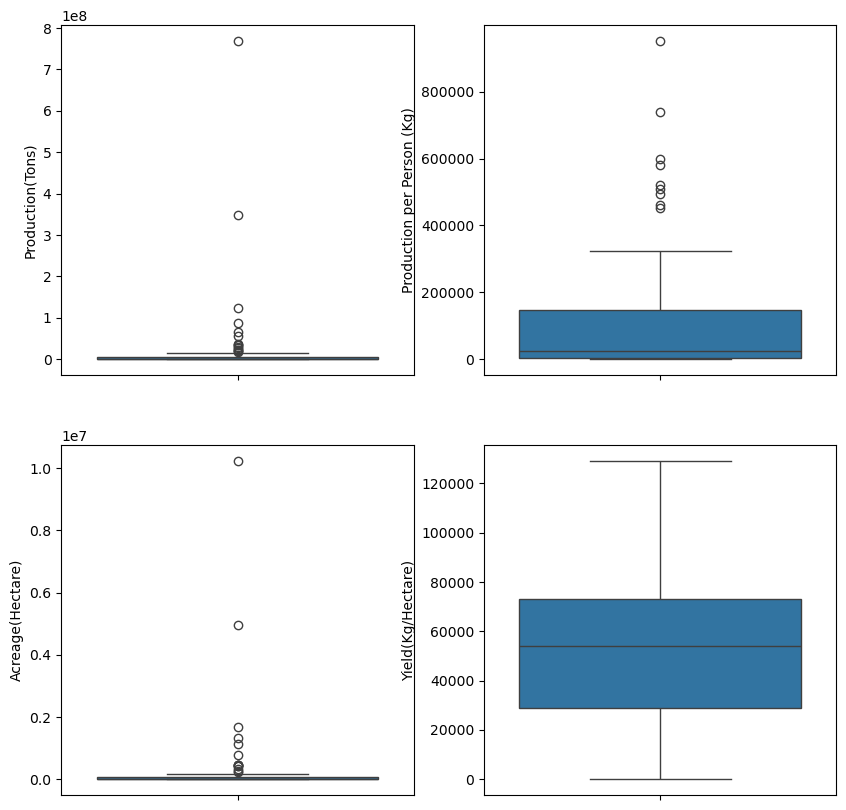

In [96]:
plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
sns.boxplot(df['Production(Tons)'])
plt.subplot(2,2,2)
sns.boxplot(df['Production per Person (Kg)'])
plt.subplot(2,2,3)
sns.boxplot(df['Acreage(Hectare)'])
plt.subplot(2,2,4)
sns.boxplot(df['Yield(Kg/Hectare)'])

In [103]:
df.describe()

,Production(Tons),Production per Person (Kg),Acreage(Hectare),Yield(Kg/Hectare)
count,1.020000e+02,102.000000,1.020000e+02,102.000000
mean,1.850372e+07,112952.435755,2.498981e+05,52628.078431
std,8.419149e+07,176651.341929,1.137003e+06,30504.676683
min,1.000000e+00,0.000000,0.000000e+00,10.000000
25%,6.251875e+04,3671.910000,1.104000e+03,29072.025000
50%,1.440044e+06,25572.500000,1.655800e+04,54108.950000
75%,6.426824e+06,146384.750000,8.047400e+04,73282.700000
max,7.686784e+08,951087.000000,1.022620e+07,129049.300000


## BiVariate Analysis

In [124]:
df_new = df[['Country','Production(Tons)']].set_index('Country')

In [126]:
df_new.head()

,Production(Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0


In [138]:
df_new['Production(Tons)_Percent'] = df_new['Production(Tons)']*100/df_new['Production(Tons)'].sum()

In [140]:
df_new.head()

,Production(Tons),Production(Tons)_Percent
Country,,
Brazil,768678382.0,40.727285
India,348448000.0,18.462001
China,123059739.0,6.520138
Thailand,87468496.0,4.634389
Pakistan,65450704.0,3.467809


<Axes: ylabel='Production(Tons)_Percent'>

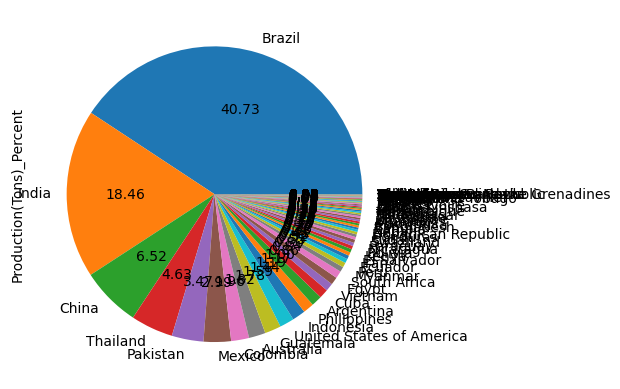

In [142]:
df_new['Production(Tons)_Percent'].plot(kind = 'pie',autopct = '%.2f')

<Axes: xlabel='Country'>

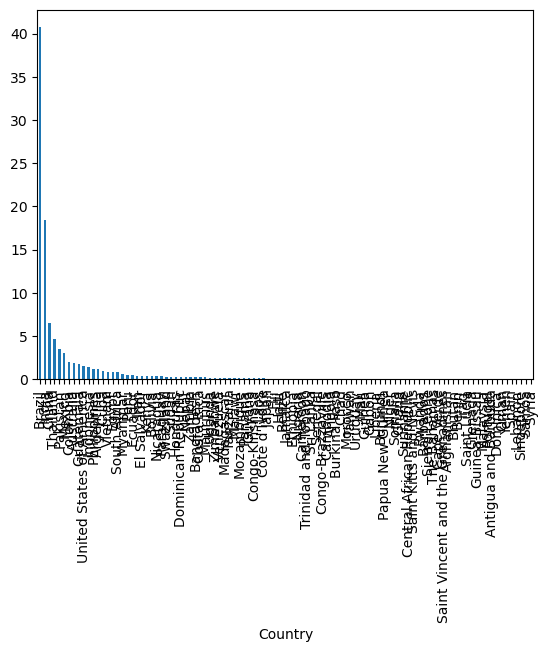

In [144]:
df_new['Production(Tons)_Percent'].plot(kind = 'bar')

<Axes: xlabel='Country'>

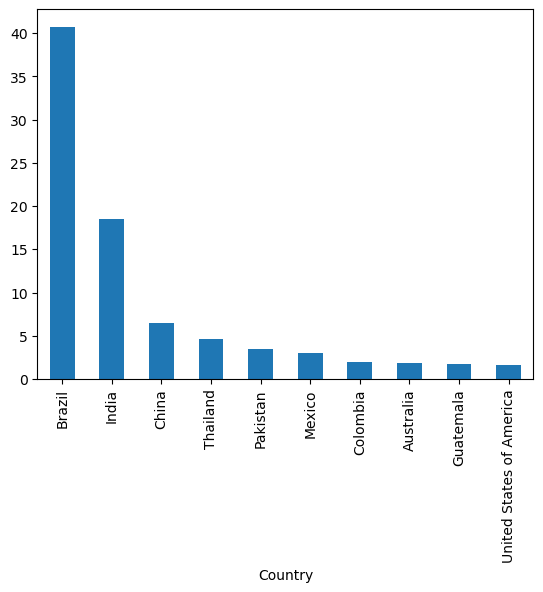

In [146]:
df_new['Production(Tons)_Percent'].head(10).plot(kind = 'bar')

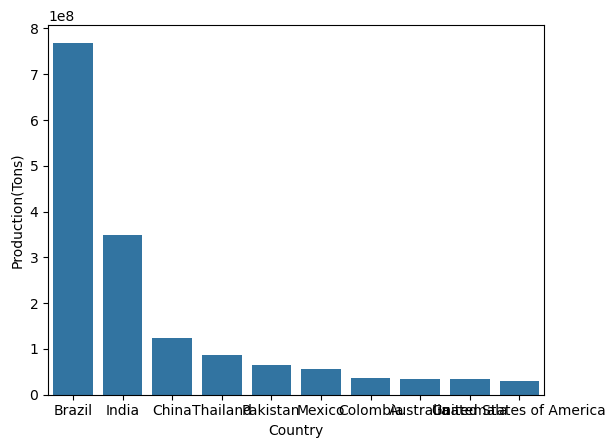

In [148]:
ax = sns.barplot(data = df.head(10) ,x='Country',y='Production(Tons)')	

#### Since the values are overlapping we need to rotate it by 90.

/var/folders/ds/9lm2vt094hjggynjhw3k36t40000gn/T/ipykernel_46428/2982271006.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


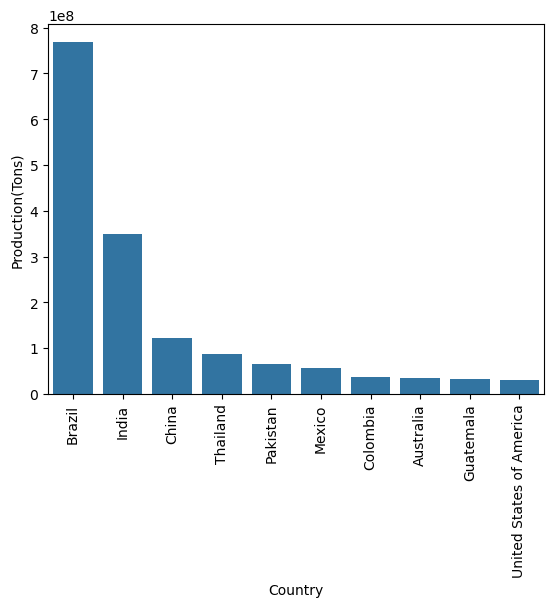

In [155]:
ax = sns.barplot(data = df.head(10) ,x='Country',y='Production(Tons)')	
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

# Q) Countries That have Highest Land?

/var/folders/ds/9lm2vt094hjggynjhw3k36t40000gn/T/ipykernel_46428/1432425535.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


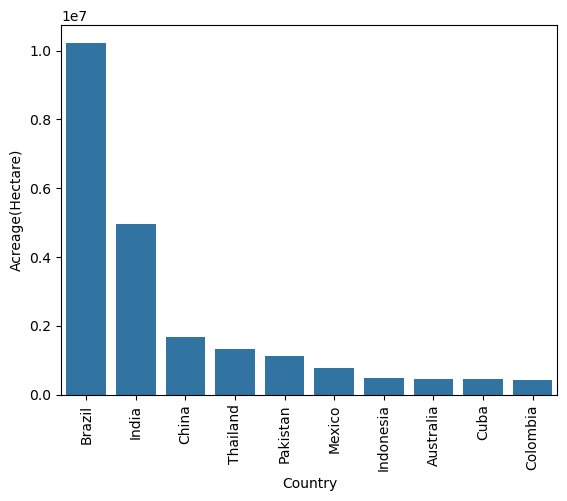

In [164]:
df_acr = df.sort_values('Acreage(Hectare)',ascending = False)
ax = sns.barplot(df_acr.head(10), x = 'Country',y = 'Acreage(Hectare)')
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

# Q) Which Country has Highest Yield per Hectare?

/var/folders/ds/9lm2vt094hjggynjhw3k36t40000gn/T/ipykernel_46428/503478947.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


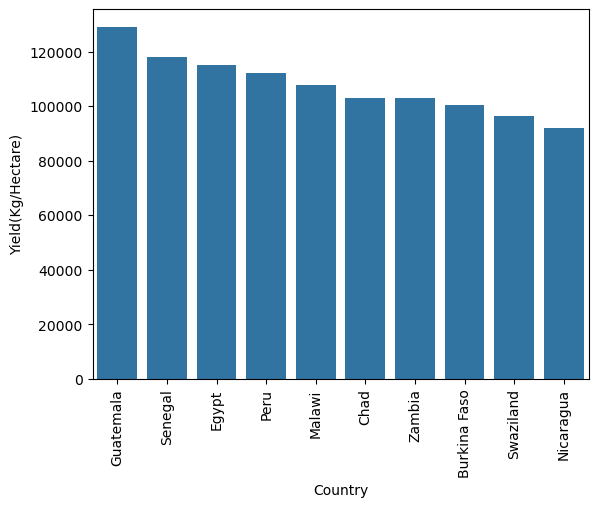

In [169]:
df_yield = df.sort_values('Yield(Kg/Hectare)',ascending = False)
ax = sns.barplot(df_yield.head(10), x = 'Country',y = 'Yield(Kg/Hectare)')
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

# Which Country has the Highest Production Per Kg?

/var/folders/ds/9lm2vt094hjggynjhw3k36t40000gn/T/ipykernel_46428/4189864414.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)


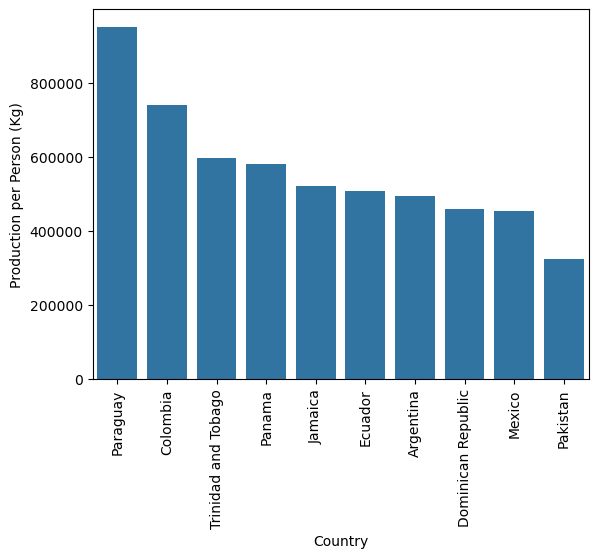

In [174]:
df_high = df.sort_values('Production per Person (Kg)',ascending = False)
ax = sns.barplot(data = df_high.head(10),x='Country',y= 'Production per Person (Kg)')
ax.set_xticklabels(ax.get_xticklabels(),rotation = 90)
plt.show()

# Correlation

In [180]:
df.corr(numeric_only = True)

,Production(Tons),Production per Person (Kg),Acreage(Hectare),Yield(Kg/Hectare)
Production(Tons),1.000000,0.015000,0.997550,0.132812
Production per Person (Kg),0.015000,1.000000,0.012557,0.017999
Acreage(Hectare),0.997550,0.012557,1.000000,0.113433
Yield(Kg/Hectare),0.132812,0.017999,0.113433,1.000000


<Axes: >

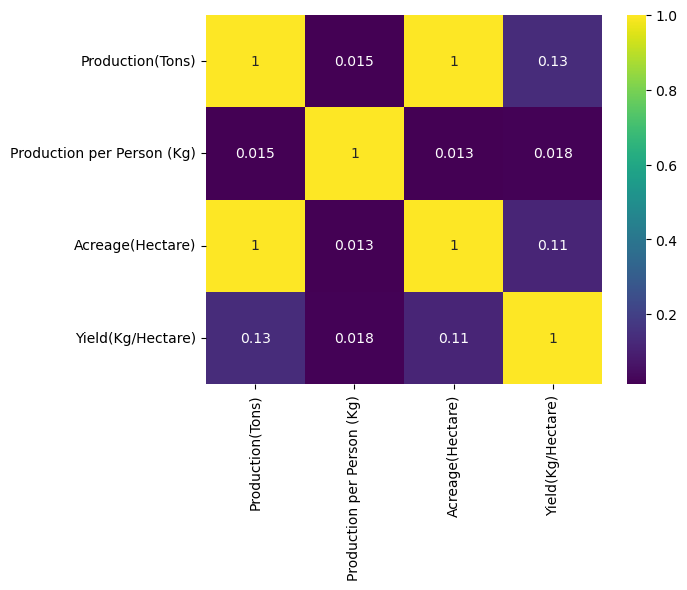

In [188]:
sns.heatmap(data = df.corr(numeric_only = True),annot=True,cmap='viridis')

# Do Countries with highest land Produce more Sugarcane?

<Axes: xlabel='Acreage(Hectare)', ylabel='Production(Tons)'>

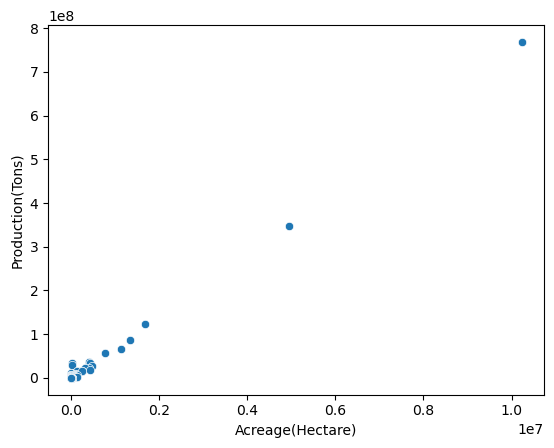

In [191]:
sns.scatterplot(data = df,x = 'Acreage(Hectare)', y= 'Production(Tons)')

# Do countries which yield more sugarcane per hectare yield more sugarcane in total?

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Production(Tons)'>

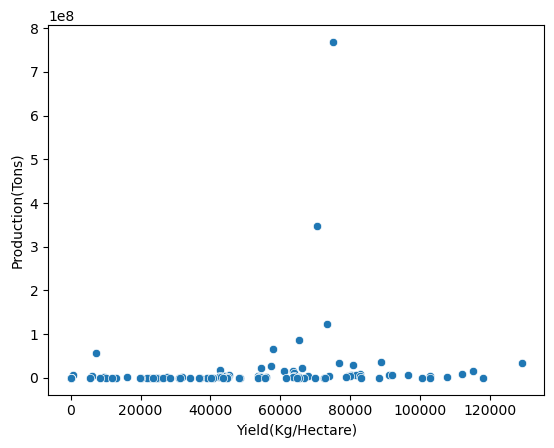

In [194]:
sns.scatterplot(data = df,x = 'Yield(Kg/Hectare)', y= 'Production(Tons)')

# Analysis Based Upon Continent

## Which Continent Produces more amount of sugarcane?

In [198]:
df['Continent'].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

In [206]:
df_continent = df.groupby('Continent').sum()

<Axes: xlabel='Continent'>

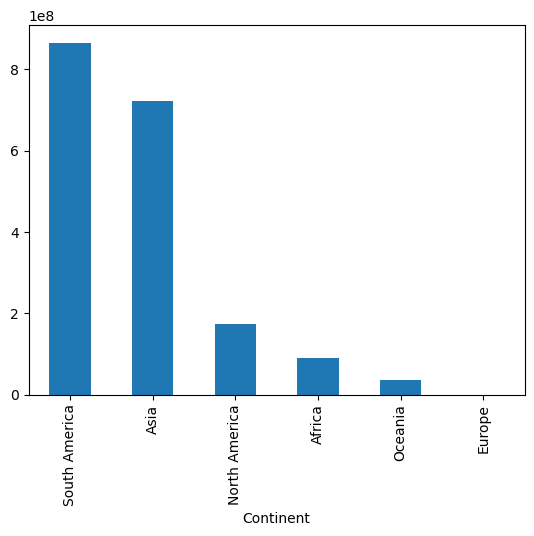

In [208]:
df_continent['Production(Tons)'] .sort_values(ascending = False).plot(kind = 'bar')

In [214]:
df_continent['number_of_countries'] = df.groupby('Continent').count()['Country']

In [216]:
df_continent

,Country,Production(Tons),Production per Person (Kg),Acreage(Hectare),Yield(Kg/Hectare),number_of_countries
Continent,,,,,,
Africa,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681472.0,2332636.293,1439089.0,2142107.5,38
Asia,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425.0,1857769.303,10608319.0,1171871.4,25
Europe,PortugalSpain,5823.0,536.000,71.0,131870.9,2
North America,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947.0,3796081.508,1581983.0,1082602.4,22
Oceania,AustraliaFijiPapua New GuineaSamoa,36177574.0,28593.605,490909.0,162419.1,4
South America,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126.0,3505531.738,11369236.0,677192.7,11


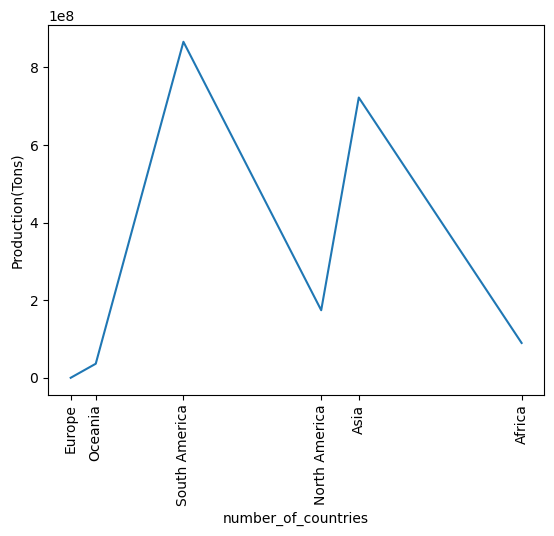

In [222]:
continent_names = df_continent.index.to_list()
sns.lineplot(data = df_continent,x='number_of_countries',y='Production(Tons)')
plt.xticks(df_continent['number_of_countries'],continent_names,rotation = 90)
plt.show()

# Correlation for Continent

In [227]:
df_continent.corr(numeric_only = True)

,Production(Tons),Production per Person (Kg),Acreage(Hectare),Yield(Kg/Hectare),number_of_countries
Production(Tons),1.000000,0.522211,0.994897,0.091201,0.109244
Production per Person (Kg),0.522211,1.000000,0.463215,0.542961,0.540086
Acreage(Hectare),0.994897,0.463215,1.000000,0.111166,0.132817
Yield(Kg/Hectare),0.091201,0.542961,0.111166,1.000000,0.989712
number_of_countries,0.109244,0.540086,0.132817,0.989712,1.000000


## Production distribution by Continent

<Axes: ylabel='Production(Tons)'>

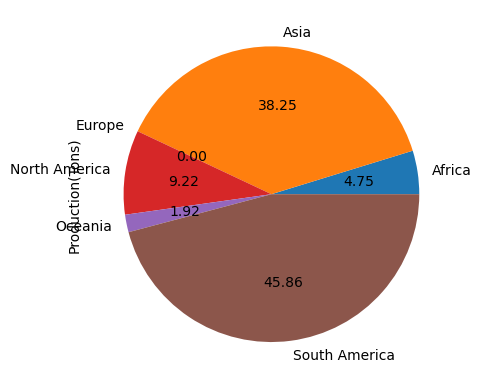

In [230]:
df_continent['Production(Tons)'].plot(kind = 'pie',autopct = '%.2f')